## Our Agenda


##### 1 What type of restaurant do the majority of customers order from?
##### 2 How many votes has each type of restaurant received from customers?
##### 3 What are the ratings that the majority of restaurants have received?
##### 4 Which mode (online or offline) has received the maximum rating?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../Dataset/Zomato data .csv')
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


#### Baisc Analysis

In [3]:
data.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [4]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


(148, 7)

In [5]:
data["online_order"].value_counts()


online_order
No     90
Yes    58
Name: count, dtype: int64

In [6]:
data["listed_in(type)"].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

<Axes: xlabel='online_order', ylabel='count'>

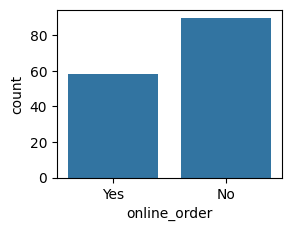

In [7]:
plt.subplot(2,2,1)
sns.countplot(x = data['online_order'])


<Axes: xlabel='online_order', ylabel='count'>

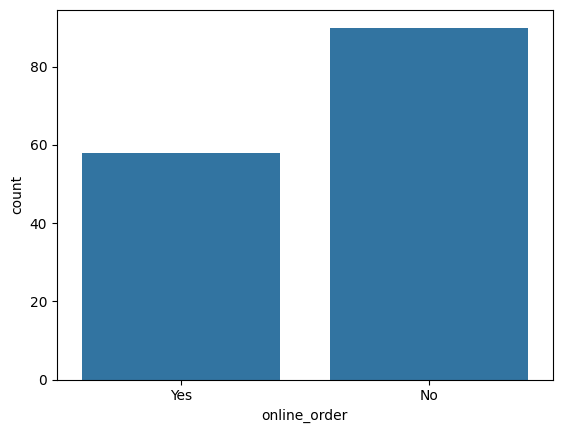

In [8]:
# plt.subplot(2,2,1)
sns.countplot(x = data['online_order'])


##### 1 What type of restaurant do the majority of customers order from?


<Axes: xlabel='listed_in(type)', ylabel='count'>

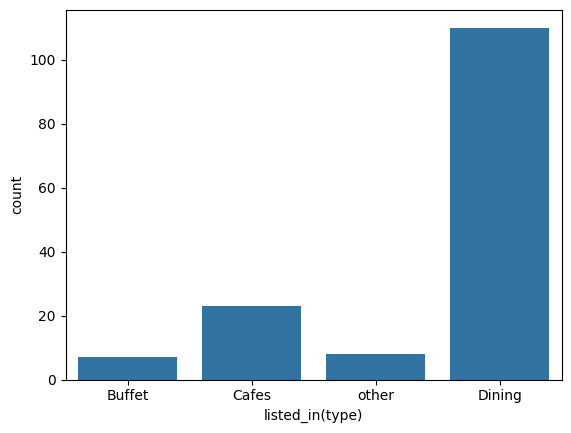

In [9]:
# plt.subplot(2,2,2)
sns.countplot(x = data['listed_in(type)'])

##### Majority customers order from Dining Restaurant


##### 2 How many votes has each type of restaurant received from customers?


In [10]:
# shows avg votes of each type 
# sns.pointplot(x = data['listed_in(type)'], y = data['votes'])

In [11]:
category_votes = data.groupby('listed_in(type)')['votes'].sum()
print(category_votes)

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64


<Axes: title={'center': 'Restaurant Type - Votes Chart'}, xlabel='Restaurant type', ylabel='count of votes'>

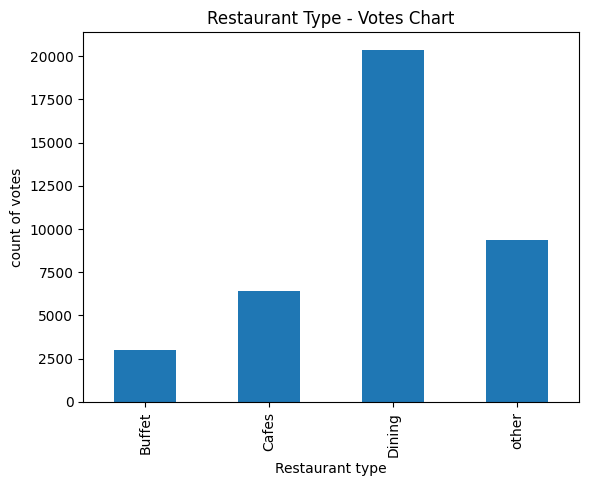

In [12]:
category_votes.plot(kind='bar', xlabel="Restaurant type", ylabel='count of votes', title="Restaurant Type - Votes Chart")

##### 3 What are the ratings that the majority of restaurants have received?



In [13]:
import numpy as np
def clean_rate(value):
    if str(value).lower() in ['new', '-', 'nan']:
        return np.nan
    else:
        value = str(value).split('/')[0]
        return float(value)

data['rate_cleaned'] = data['rate'].apply(clean_rate)

clean_data = data.dropna(subset=['rate_cleaned'])



Text(0, 0.5, 'Frequency')

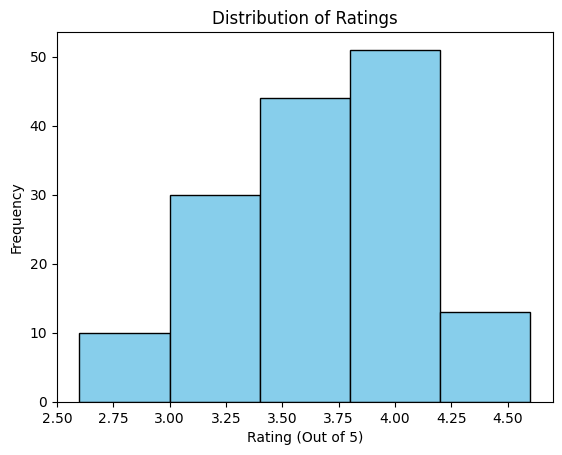

In [14]:
# 4. Now plot the histogram!
plt.hist(clean_data['rate_cleaned'], bins=5, color='skyblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating (Out of 5)')
plt.ylabel('Frequency')

##### Conclusion: The majority restaurant recieved from 3.5 to 4

##### 4 Which mode (online or offline) has received the maximum rating?


In [15]:
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),rate_cleaned
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet,4.1
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet,4.1
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet,3.8
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet,3.7
4,Grand Village,No,No,3.8/5,166,600,Buffet,3.8


<Axes: xlabel='online_order', ylabel='rate'>

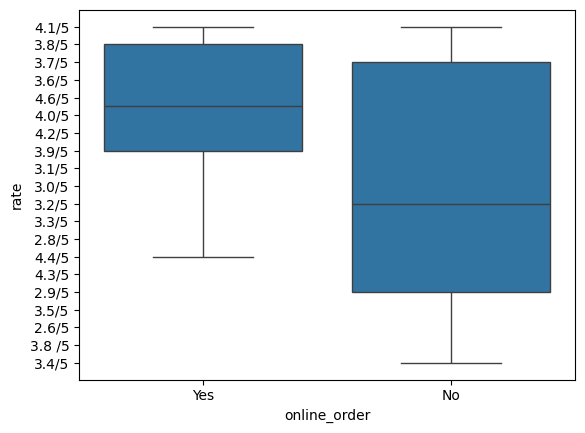

In [16]:
sns.boxplot(data= data, x = 'online_order', y = 'rate')

##### Conclusion: offline orders recieve less ratings